# Predictive Modeling and Risk Scoring for Bank Customer Churn

This notebook follows the project requirements: preprocessing, feature engineering, stratified splitting, model development, risk scoring, explainability, and Streamlit-ready outputs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.inspection import PartialDependenceDisplay
import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

DATA_PATH = Path("data/European_Bank.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Dataset overview and target definition

Target variable: `Exited` where 1 means the customer churned and 0 means the customer was retained.

In [2]:
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print(df["Exited"].value_counts(normalize=True).rename("Proportion"))
df.describe(include="all")

Shape: (10000, 14)
Missing values: 0
Exited
0    0.7963
1    0.2037
Name: Proportion, dtype: float64


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025.0,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


## 2. Exploratory data analysis

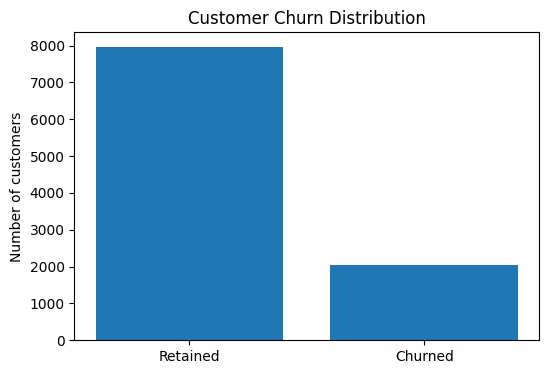

In [3]:
# Churn distribution
counts = df["Exited"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["Retained", "Churned"], counts.values)
ax.set_title("Customer Churn Distribution")
ax.set_ylabel("Number of customers")
plt.show()

In [4]:
# Churn rates by key segments
for col in ["Geography", "Gender", "IsActiveMember", "NumOfProducts"]:
    display(df.groupby(col)["Exited"].agg(["mean", "count"]).sort_values("mean", ascending=False))

,mean,count
Geography,,
Germany,0.324432,2509
Spain,0.166734,2477
France,0.161548,5014


,mean,count
Gender,,
Female,0.250715,4543
Male,0.164559,5457


,mean,count
IsActiveMember,,
0,0.268509,4849
1,0.142691,5151


,mean,count
NumOfProducts,,
4,1.000000,60
3,0.827068,266
1,0.277144,5084
2,0.075817,4590


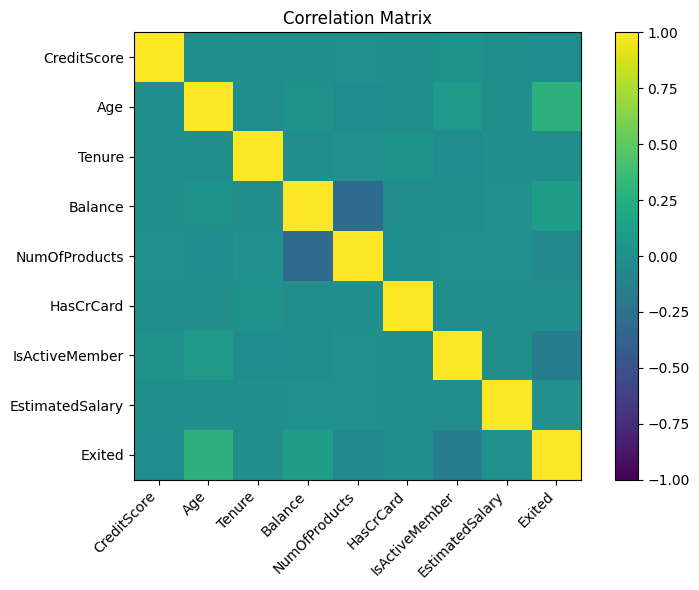

In [5]:
corr_cols = ["CreditScore","Age","Tenure","Balance","NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary","Exited"]
corr = df[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
fig.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 3. Data preprocessing and feature engineering

Non-informative columns are removed: `CustomerId`, `Surname`, and constant `Year`. Categorical columns are one-hot encoded. Numerical features are scaled.

In [6]:
def engineer_features(input_df):
    out = input_df.copy()
    out["BalanceSalaryRatio"] = out["Balance"] / (out["EstimatedSalary"] + 1.0)
    out["ProductDensity"] = out["NumOfProducts"] / (out["Tenure"] + 1.0)
    out["EngagementProductInteraction"] = out["IsActiveMember"] * out["NumOfProducts"]
    out["AgeTenureInteraction"] = out["Age"] * out["Tenure"]
    return out

model_df = engineer_features(df)
DROP_COLS = ["CustomerId", "Surname", "Year"]
FEATURES = [c for c in model_df.columns if c not in DROP_COLS + ["Exited"]]
X = model_df[FEATURES]
y = model_df["Exited"]

numeric_features = ["CreditScore","Age","Tenure","Balance","NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary",
                    "BalanceSalaryRatio","ProductDensity","EngagementProductInteraction","AgeTenureInteraction"]
categorical_features = ["Geography","Gender"]

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", encoder, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train.shape, X_test.shape

((8000, 14), (2000, 14))

## 4. Model development and evaluation

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1500, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=35, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=350, max_depth=10, min_samples_leaf=8, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=180, learning_rate=0.055, max_depth=3, random_state=42),
}
if HAS_XGB:
    models["XGBoost"] = XGBClassifier(n_estimators=220, max_depth=3, learning_rate=0.055, subsample=0.85, colsample_bytree=0.85, eval_metric="logloss", random_state=42, n_jobs=2)

results, pipelines, probas = [], {}, {}
for name, clf in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, p),
    })
    pipelines[name] = pipe
    probas[name] = p

metrics_df = pd.DataFrame(results).sort_values(["ROC-AUC", "F1-Score"], ascending=False)
metrics_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost,0.8695,0.789683,0.488943,0.603945,0.869113
3,Gradient Boosting,0.8700,0.792829,0.488943,0.604863,0.868248
2,Random Forest,0.8320,0.572301,0.690418,0.625835,0.864101
1,Decision Tree,0.7570,0.445215,0.788698,0.569149,0.838374
0,Logistic Regression,0.7095,0.382749,0.697789,0.494343,0.775921


Best model: XGBoost


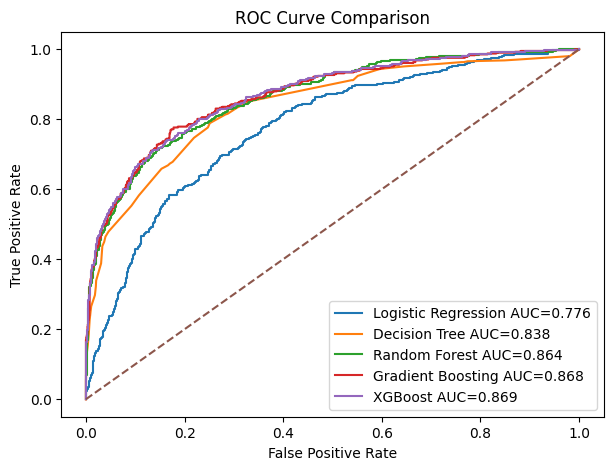

In [8]:
best_name = metrics_df.iloc[0]["Model"]
best_model = pipelines[best_name]
best_proba = probas[best_name]
print("Best model:", best_name)

fig, ax = plt.subplots(figsize=(7,5))
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, label=f"{name} AUC={roc_auc_score(y_test, p):.3f}")
ax.plot([0,1], [0,1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()

## 5. Threshold tuning for risk flagging

The dashboard uses probabilities for risk bands. A threshold is also selected for binary churn flags, prioritizing precision to control false churn alarms while keeping recall usable.

In [9]:
threshold = 0.2523198127746582
pred = (best_proba >= threshold).astype(int)
print("Threshold:", threshold)
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))

Threshold: 0.2523198127746582
Confusion matrix:
[[1360  233]
 [ 115  292]]
Precision: 0.5561904761904762
Recall: 0.7174447174447175
F1: 0.6266094420600858


## 6. Explainability: feature importance and partial dependence

In [10]:
pre = best_model.named_steps["preprocessor"]
try:
    ohe_names = list(pre.named_transformers_["cat"].get_feature_names_out(categorical_features))
except Exception:
    ohe_names = []
feature_names = numeric_features + ohe_names
clf = best_model.named_steps["classifier"]

if hasattr(clf, "feature_importances_"):
    imp = clf.feature_importances_
elif hasattr(clf, "coef_"):
    imp = abs(clf.coef_).ravel()
else:
    imp = np.zeros(len(feature_names))

feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": imp}).sort_values("Importance", ascending=False)
feature_importance.head(15)

,Feature,Importance
10,EngagementProductInteraction,0.174785
4,NumOfProducts,0.153603
1,Age,0.151102
6,IsActiveMember,0.109187
13,Geography_Germany,0.093628
16,Gender_Male,0.051538
15,Gender_Female,0.046297
3,Balance,0.042587
8,BalanceSalaryRatio,0.032994
12,Geography_France,0.025224


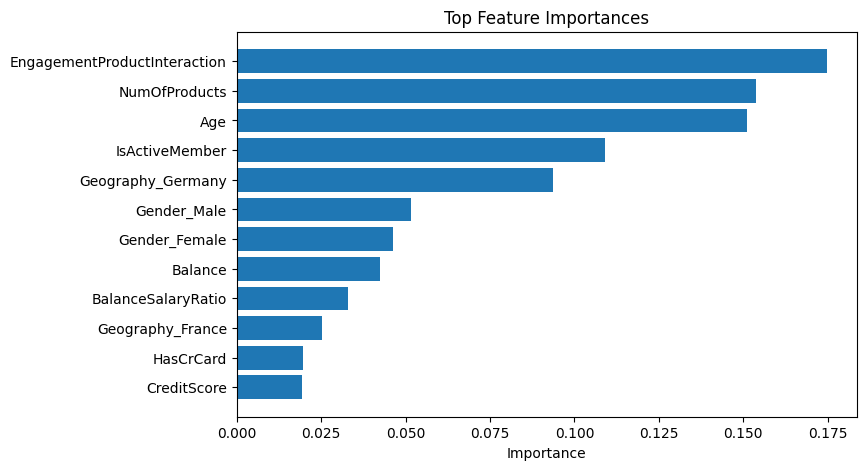

In [11]:
top = feature_importance.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top["Feature"], top["Importance"])
ax.set_title("Top Feature Importances")
ax.set_xlabel("Importance")
plt.show()

/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


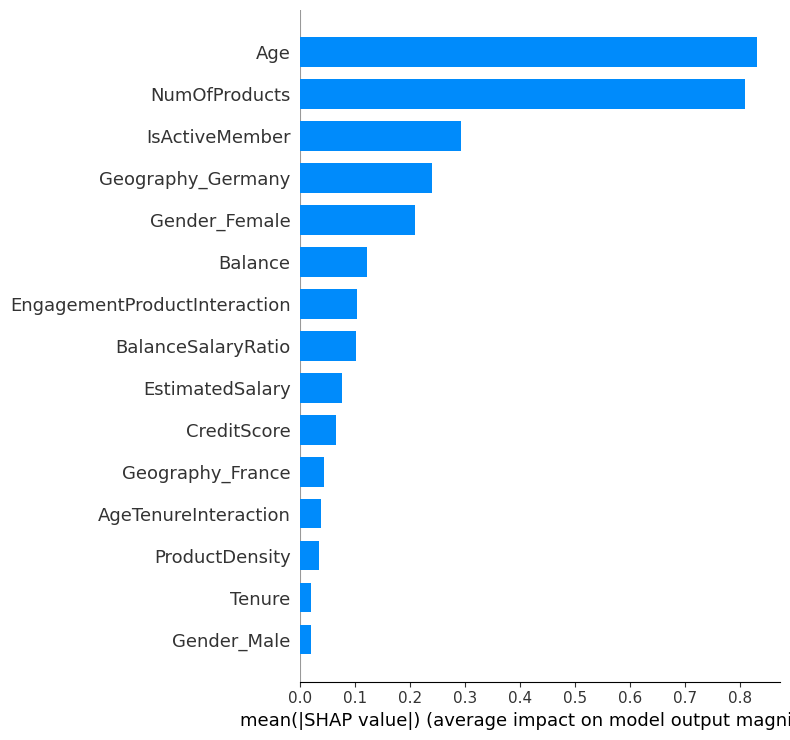

In [12]:
# SHAP summary bar chart for model explainability
# This is generated for the final tree-based model after preprocessing.
try:
    import shap
    transformed = best_model.named_steps["preprocessor"].transform(X_test)
    sample_n = min(1000, transformed.shape[0])
    explainer = shap.TreeExplainer(best_model.named_steps["classifier"])
    shap_values = explainer.shap_values(transformed[:sample_n])
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[-1]
    else:
        shap_values_plot = shap_values
    shap.summary_plot(
        shap_values_plot,
        transformed[:sample_n],
        feature_names=feature_names,
        plot_type="bar",
        show=True,
        max_display=15
    )
except Exception as e:
    print("SHAP could not be generated in this environment:", e)

/opt/pyvenv/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


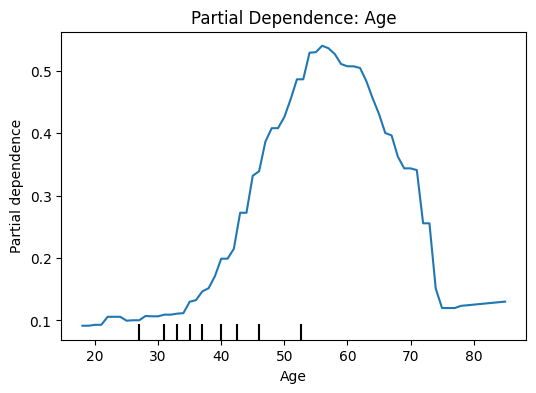

/opt/pyvenv/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 6 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


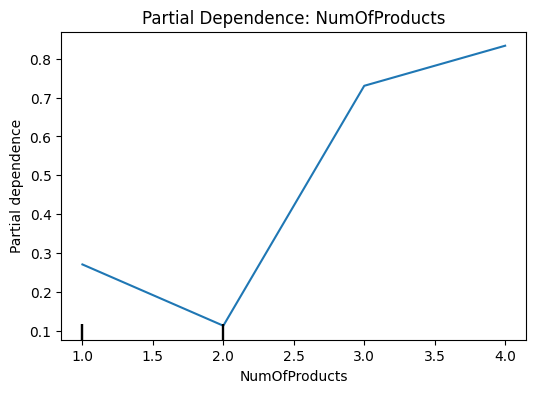

/opt/pyvenv/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 8 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


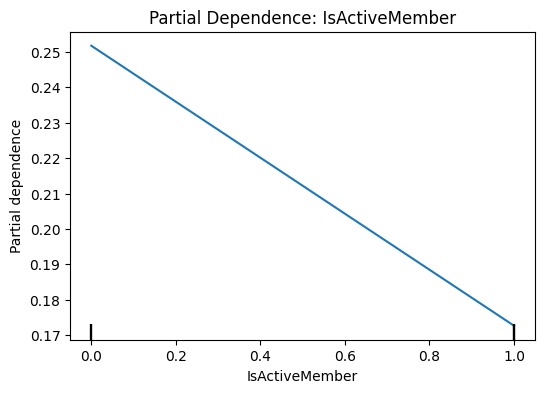

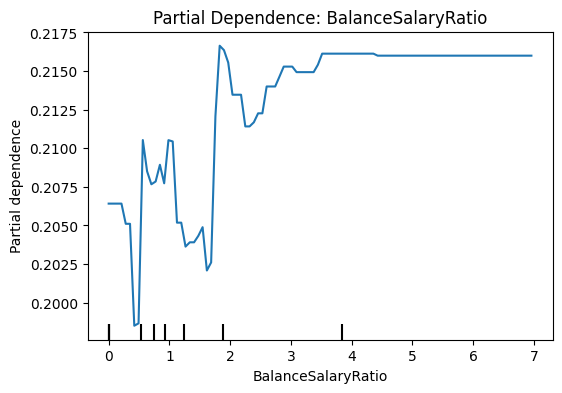

In [13]:
for feat in ["Age", "NumOfProducts", "IsActiveMember", "BalanceSalaryRatio"]:
    fig, ax = plt.subplots(figsize=(6,4))
    PartialDependenceDisplay.from_estimator(best_model, X_test, [feat], ax=ax)
    ax.set_title(f"Partial Dependence: {feat}")
    plt.show()

## 7. Risk scoring output

In [14]:
full_proba = best_model.predict_proba(X)[:,1]
risk_df = df[["CustomerId","Surname","Geography","Gender","Age","Tenure","Balance","NumOfProducts","IsActiveMember","EstimatedSalary","Exited"]].copy()
risk_df["ChurnProbability"] = full_proba
risk_df["RiskScore"] = (full_proba * 100).round(2)
risk_df["RiskBand"] = pd.cut(full_proba, bins=[-0.001,0.30,0.60,1.0], labels=["Low","Medium","High"])
risk_df["ChurnFlag"] = (full_proba >= threshold).astype(int)
risk_df.sort_values("ChurnProbability", ascending=False).head(20)

,CustomerId,Surname,Geography,Gender,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,ChurnProbability,RiskScore,RiskBand,ChurnFlag
70,15703793,Konovalova,Germany,Male,58,2,133745.44,4,0,28373.86,1,0.998350,99.830002,High,1
4013,15653776,Salier,Germany,Female,57,1,162082.31,4,0,27145.73,1,0.997471,99.750000,High,1
8923,15570002,Burlingame,Germany,Female,55,8,118772.71,4,0,135853.62,1,0.996512,99.650002,High,1
2614,15640846,Chibueze,Germany,Female,58,3,106458.31,4,0,128881.87,1,0.996016,99.599998,High,1
6279,15608338,Chiemenam,Spain,Female,55,9,117294.12,4,0,94187.47,1,0.995550,99.559998,High,1
4014,15597914,Evdokimov,Germany,Female,51,2,117306.69,4,1,26912.72,1,0.993963,99.400002,High,1
1962,15692416,Aikenhead,Spain,Female,52,8,143542.36,3,0,141959.11,1,0.993277,99.330002,High,1
1265,15662291,Davidson,France,Female,55,8,116973.26,3,0,122066.50,1,0.992788,99.279999,High,1
2495,15666548,Chung,Germany,Female,56,2,111920.13,3,0,197634.11,1,0.992328,99.230003,High,1
5950,15806808,Hope,Germany,Female,57,8,112281.60,3,0,140225.14,1,0.992165,99.220001,High,1


## 8. Business recommendations

- Prioritize high-risk customers for proactive retention campaigns.
- Use product and engagement changes in the what-if simulator to test retention levers.
- Monitor inactive customers and customers with high balance-to-salary ratios more closely.
- Treat probability scores as prioritization inputs, not automatic rejection or exclusion decisions.

In [15]:
# Save final artifacts
joblib.dump(best_model, "models/bank_churn_model.joblib")
metrics_df.to_csv("model_metrics.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)
risk_df.sort_values("ChurnProbability", ascending=False).to_csv("risk_scored_customers.csv", index=False)